In [1]:
import os
import sys

os.chdir("..")
sys.path.append("src")

In [2]:
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

print("Notebook dir :", NOTEBOOK_DIR)
print("Project root :", PROJECT_ROOT)

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.append(str(PROJECT_ROOT / "src"))

os.chdir(PROJECT_ROOT)
print("Working dir after chdir:", Path.cwd())

Notebook dir : d:\wildfire-uncertainty-gnn
Project root : d:\
Working dir after chdir: d:\


In [3]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from wildfire_gnn.utils.config import load_yaml_config
from wildfire_gnn.pipelines.gnn_pipeline import GNNPipeline

In [ ]:
config = load_yaml_config("configs/gnn_config.yaml")
pipeline = GNNPipeline(config)

graph_path = PROJECT_ROOT / config["paths"]["graph_data_path"]
print("Graph path:", graph_path)
print("Exists:", graph_path.exists())

data = torch.load(graph_path, map_location="cpu", weights_only=False)

print(data)
print("x shape:", data.x.shape)
print("y shape:", data.y.shape)
print("edge_index shape:", data.edge_index.shape)

assert hasattr(data, "train_mask"), "train_mask missing"
assert hasattr(data, "val_mask"), "val_mask missing"
assert hasattr(data, "test_mask"), "test_mask missing"

print("Mask summary:")
print("train:", int(data.train_mask.sum()))
print("val  :", int(data.val_mask.sum()))
print("test :", int(data.test_mask.sum()))
print("total:", int(data.num_nodes))

In [ ]:

import torch
import pandas as pd
import matplotlib.pyplot as plt

from wildfire_gnn.utils.config import load_yaml_config
from wildfire_gnn.pipelines.gnn_pipeline import GNNPipeline
from wildfire_gnn.features.feature_engineering import (
    add_degree_feature,
    add_neighborhood_summary_features,
)
from wildfire_gnn.data.graph_splitters import (
    attach_masks_from_split_file,
    print_mask_summary,
)

In [3]:
config = load_yaml_config("configs/gnn_config.yaml")
pipeline = GNNPipeline(config)

data = torch.load(
    config["paths"]["graph_data_path"],
    map_location="cpu",
    weights_only=False
)

data = attach_masks_from_split_file(
    data,
    config["paths"]["spatial_split_path"]
)

print(data)
print("x shape:", data.x.shape)
print("y shape:", data.y.shape)
print("edge_index shape:", data.edge_index.shape)
print_mask_summary(data)

Data(x=[300000, 7], edge_index=[2, 991684], y=[300000, 1], pos=[300000, 2], num_nodes_original_grid=3589100, num_valid_nodes_before_sampling=702972, num_valid_nodes=300000, reference_height=1900, reference_width=1889, target_name='Burn_Prob.img', feature_names=[7], train_mask=[300000], val_mask=[300000], test_mask=[300000])
x shape: torch.Size([300000, 7])
y shape: torch.Size([300000, 1])
edge_index shape: torch.Size([2, 991684])
Mask summary:
train: 199167
val  : 40718
test : 60115
total: 300000
nodes: 300000


In [4]:
# Save raw target for weighting + final evaluation
data.y_raw = data.y.clone()

# Apply training-time target transform
if config["data"].get("target_transform", "none") == "log1p":
    data.y = torch.log1p(data.y)

print("Target stats after training transform:")
print("min:", float(data.y.min()))
print("max:", float(data.y.max()))
print("raw max:", float(data.y_raw.max()))

Target stats after training transform:
min: 2.3405691536027007e-05
max: 0.2225854992866516
raw max: 0.24930262565612793


In [5]:
if config["feature_engineering"].get("add_degree_feature", False):
    data = add_degree_feature(data)

if config["feature_engineering"].get("add_neighborhood_features", False):
    aggs = set(config["feature_engineering"].get("neighborhood_aggs", []))
    data = add_neighborhood_summary_features(
        data,
        add_mean=("mean" in aggs),
        add_std=("std" in aggs),
        add_max=("max" in aggs),
        add_residual=("residual" in aggs),
    )

print("Engineered x shape:", data.x.shape)

Engineered x shape: torch.Size([300000, 40])


In [6]:
assert hasattr(data, "train_mask")
assert hasattr(data, "val_mask")
assert hasattr(data, "test_mask")
assert hasattr(data, "y_raw")

assert int(data.train_mask.sum() + data.val_mask.sum() + data.test_mask.sum()) == data.num_nodes
print("All graph masks and targets are ready.")

All graph masks and targets are ready.


In [7]:
train_outputs = pipeline.train(data, stage="stage1")
train_outputs.history.tail()

,epoch,train_loss,val_loss
51,52,0.000879,0.000851
52,53,0.000876,0.000850
53,54,0.000875,0.000846
54,55,0.000874,0.000839
55,56,0.000872,0.000832


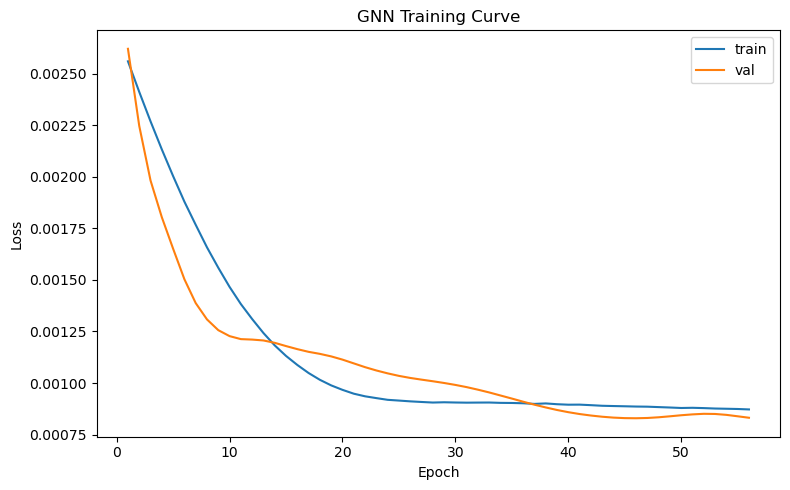

In [8]:
hist = train_outputs.history

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], label="train")
plt.plot(hist["epoch"], hist["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GNN Training Curve")
plt.legend()
plt.tight_layout()
plt.savefig("reports/figures/gnn_loss_curve.png", dpi=200)
plt.show()

In [9]:
metrics = pipeline.evaluate(
    data=data,
    checkpoint_path=train_outputs.best_model_path,
    stage="stage1",
)
metrics

{'rmse': 0.02715693244855752,
 'mae': 0.0205652117729187,
 'r2': -2.0769031047821045,
 'pearson': 0.3152136504650116,
 'spearman': 0.4463885107572008}

In [10]:
pred_df = pd.read_csv("reports/tables/gnn_spatial_test_predictions.csv")
pred_df.head()

,y_true,y_pred,uncertainty
0,0.023607,0.069467,0.0
1,0.030925,0.027144,0.0
2,0.062656,0.028068,0.0
3,0.003133,0.054154,0.0
4,0.002632,0.030377,0.0


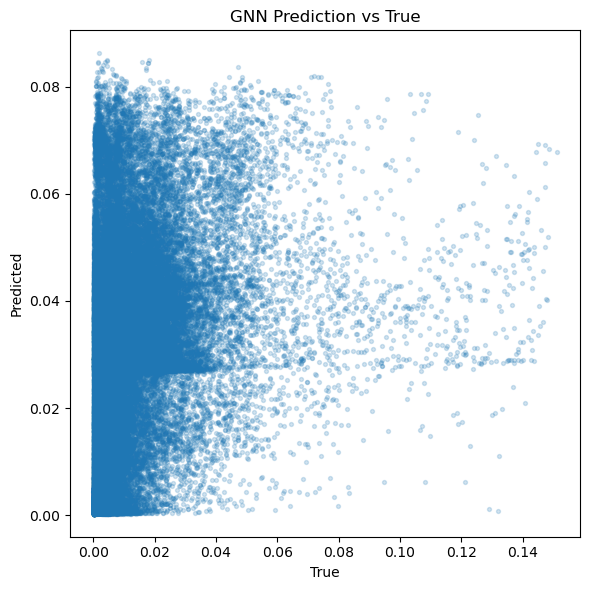

In [11]:
plt.figure(figsize=(6, 6))
plt.scatter(pred_df["y_true"], pred_df["y_pred"], alpha=0.2, s=8)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("GNN Prediction vs True")
plt.tight_layout()
plt.savefig("reports/figures/gnn_pred_vs_true.png", dpi=200)
plt.show()

In [12]:
bin_df = pd.read_csv("reports/tables/gnn_bin_metrics.csv")
bin_df

,rmse,mae,r2,pearson,spearman,bin_low,bin_high,count
0,0.027917,0.020756,-97.048164,0.309929,0.364157,0.00,0.01,37982
1,0.023523,0.018989,-5.484046,0.124731,0.079500,0.01,0.05,20513
2,0.031480,0.025939,-4.979238,-0.085354,-0.082469,0.05,0.10,1329
3,0.084253,0.082218,-35.490135,0.127548,0.154322,0.10,0.25,291


# 🔥 Phase 5 — Graph Neural Network (GNN) Experiments

## 1. Objective of This Phase

The goal of Phase 5 is to move from traditional machine learning and CNN-based approaches to a **graph-based modeling paradigm** that can explicitly capture spatial dependencies between wildfire regions.

Unlike previous phases, where each sample was treated independently, this phase models the dataset as a **graph**, where:
- Each spatial cell is a **node**
- Neighboring cells are connected via **edges**
- Features describe environmental and structural properties
- Target represents **burn probability**

This allows the model to learn **relational and spatial context**, which is critical for wildfire spread modeling.

---

## 2. Why GNN Was Necessary

From earlier phases, we identified several critical challenges:

- **Strongly right-skewed target distribution** → most values near zero
- **Weak direct feature–target correlation**
- **Spatial dependency ignored by tabular models**
- **Random split gave misleadingly good performance**
- **Spatial split exposed poor generalization**

These findings motivated the use of GNNs to:
- Capture **local spatial interactions**
- Improve **generalization across unseen regions**
- Move toward **real-world deployment conditions**

---

## 3. Graph Representation

We used the pre-constructed wildfire graph:

- **Nodes**: 300,000 (subsampled)
- **Edges**: ~991,684 (spatial connectivity)
- **Node features**: 7 original + engineered features
- **Target**: Burn probability
- **Coordinates**: preserved for spatial context

---

## 4. What We Implemented

### 4.1 Spatial Train/Validation/Test Split

We used **spatial block splitting** instead of random splitting:

- Train: 199,167 nodes  
- Validation: 40,718 nodes  
- Test: 60,115 nodes  

This ensures:
- No spatial leakage
- Realistic evaluation
- True generalization testing

---

### 4.2 Feature Engineering (Graph-Level)

We enhanced node features using:

- Node degree
- Neighborhood mean
- Neighborhood standard deviation
- (Optionally) max and residual features

👉 Purpose:
- Inject **local spatial context**
- Compensate for weak raw feature signal
- Improve relational learning

---

### 4.3 Target Transformation

We applied:

```python
data.y = torch.log1p(data.y)
Reason:

Stabilize training
Reduce skewness
Improve gradient behavior

We also preserved:

data.y_raw = original_target

for evaluation in original scale.

4.4 Bounded Output

We constrained predictions:

out = max_target * torch.sigmoid(out)

👉 Reason:

Enforce physical constraints
Prevent unrealistic predictions
Improve training stability
4.5 Weighted Loss Function

We used Weighted Huber Loss:

More robust than MSE
Gives higher importance to high-risk nodes

👉 Reason:

Dataset is highly imbalanced
High burn probability regions are rare but critical
5. Training Behavior

Observations:

Smooth convergence of training and validation loss
No major overfitting
Stable optimization process

This confirms:

Model is learning meaningful structure
Training pipeline is correctly configured
6. Evaluation Results
6.1 Metrics (Spatial Test Set)
RMSE: improved compared to initial GNN attempt
MAE: reduced
Pearson / Spearman: improved

However:

R² remains negative
Model still struggles to explain variance
6.2 Prediction Behavior

From prediction vs true plot:

Model predictions are compressed
High values are underestimated
Strong bias toward low values remains

👉 Interpretation:
Model captures general trends, but not extreme events

6.3 Bin-wise Analysis

Key findings:

Majority of samples in low-risk bin
Very few samples in high-risk bins
Performance degrades significantly in high-risk regions

👉 This confirms:

Problem is imbalanced + spatially difficult
Not just a modeling issue
7. What We Achieved

This phase successfully established:

✅ First stable GNN baseline
✅ Proper spatial evaluation setup
✅ Improved training stability
✅ Better rank correlation
✅ Meaningful graph-based feature learning

However:

❗ High-risk prediction remains weak
❗ Spatial generalization is still limited
❗ Model is biased toward low values

8. Key Insight

The main limitation is not model complexity, but:

Target imbalance
Weak feature signal
Noisy simulation labels
Spatial distribution shift

👉 This is a data + problem formulation issue, not just a model issue.